<a href="https://colab.research.google.com/github/yurayura3812-svg/clocr/blob/main/app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

【1】服装の写真をアップロードしてください。


Saving スクリーンショット 2026-06-16 114312.png to スクリーンショット 2026-06-16 114312 (1).png

【2】AI（MediaPipe）で人物領域を抽出中...
【3】OpenCVで「肌色ノイズ」を自動検出して除外中...
【4】バウンディングボックスによる面積の正規化（アングル・ポーズ補正）を実行中...
 -> 正規化分母（人物のバウンディングボックス面積）: 147543 ピクセル

--- 【5】正規化＆肌色排除後の純粋衣服カラー比率 ---
色 (RGB: [156  40 141]) : 36.0%
色 (RGB: [55 57 75]) : 34.3%
色 (RGB: [30 30 35]) : 20.9%
色 (RGB: [105  42  94]) : 8.9%


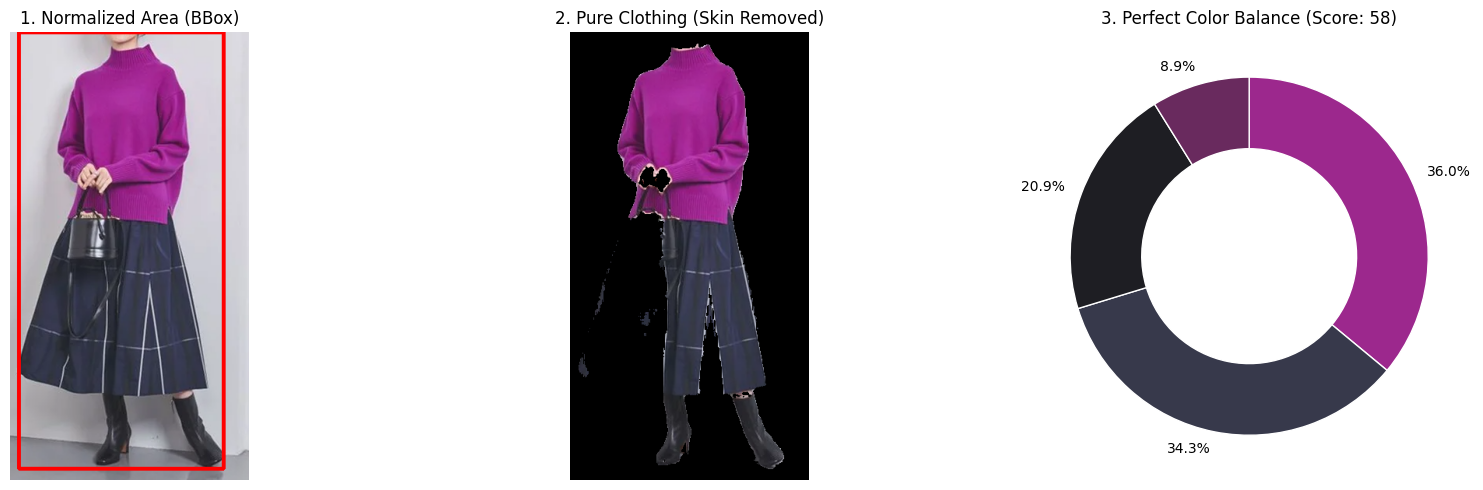

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from google.colab import files

def analyze_perfect_color_balance():
    # 1. 画像のアップロード
    print("【1】服装の写真をアップロードしてください。")
    uploaded = files.upload()

    if not uploaded:
        print("ファイルがアップロードされませんでした。")
        return

    # 画像の読み込みとリサイズ
    file_name = list(uploaded.keys())[0]
    file_bytes = np.frombuffer(uploaded[file_name], np.uint8)
    img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    height, width = img_rgb.shape[:2]
    max_size = 600
    if max(height, width) > max_size:
        scale = max_size / max(height, width)
        img_rgb = cv2.resize(img_rgb, (int(width * scale), int(height * scale)))
        height, width = img_rgb.shape[:2]

    # 2. AIによる人物切り抜き
    print("\n【2】AI（MediaPipe）で人物領域を抽出中...")
    from mediapipe.tasks import python
    from mediapipe.tasks.python import vision

    model_path = "selfie_segmenter.tflite"
    options = vision.ImageSegmenterOptions(
        base_options=python.BaseOptions(model_asset_path=model_path),
        output_category_mask=False,
        output_confidence_masks=True
    )

    with vision.ImageSegmenter.create_from_options(options) as segmenter:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        segmentation_result = segmenter.segment(mp_image)
        raw_confidence_mask = segmentation_result.confidence_masks[0].numpy_view()
        confidence_mask = np.squeeze(raw_confidence_mask)
        person_mask = (confidence_mask > 0.5).astype(np.uint8)

    # -------------------------------------------------------------
    # イノベーション①: OpenCVによる「肌色」の自動マスキング除外
    # -------------------------------------------------------------
    print("【3】OpenCVで「肌色ノイズ」を自動検出して除外中...")
    # 画像をHSV空間に変換して肌色の範囲を定義（光の変動に対応）
    img_hsv_init = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # 一般的な日本人の肌色HSV範囲
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([25, 150, 255], dtype=np.uint8)

    # 肌色エリアのマスクを作成
    skin_mask = cv2.inRange(img_hsv_init, lower_skin, upper_skin)

    # 人物マスクから肌色マスクを引き算（人物領域から肌を消す）
    pure_clothing_mask = cv2.bitwise_and(person_mask, cv2.bitwise_not(skin_mask // 255))

    # 背景と肌色を「黒（0）」にした、純粋な「服だけ画像」を生成
    img_pure_clothing = img_rgb * pure_clothing_mask[:, :, np.newaxis]

    # -------------------------------------------------------------
    # イノベーション②: 先生の指摘を解決する「バウンディングボックスによる正規化」
    # -------------------------------------------------------------
    print("【4】バウンディングボックスによる面積の正規化（アングル・ポーズ補正）を実行中...")
    # 人物が写っている領域の座標（上下左右の端）を取得
    y_indices, x_indices = np.where(person_mask > 0)

    if len(y_indices) > 0 and len(x_indices) > 0:
        ymin, ymax = np.min(y_indices), np.max(y_indices)
        xmin, xmax = np.min(x_indices), np.max(x_indices)
        # 人物の最小外接矩形（バウンディングボックス）の面積を分母にする（正規化）
        bbox_area = (ymax - ymin) * (xmax - xmin)
        print(f" -> 正規化分母（人物のバウンディングボックス面積）: {bbox_area} ピクセル")
    else:
        bbox_area = width * height
        ymin, ymax, xmin, xmax = 0, height, 0, width

    # 3. 前処理（OpenCV）：シワを滑らかにする
    img_blurred = cv2.GaussianBlur(img_pure_clothing, (15, 15), 0)
    img_hsv = cv2.cvtColor(img_blurred, cv2.COLOR_RGB2HSV)
    pixels = img_hsv.reshape((-1, 3))
    pixels = np.float32(pixels)

    # 4. クラスタリング（OpenCV）：k-means法
    K = 6
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # 5. 面積比率の計算（正規化ベース）
    labels = labels.flatten()
    counts = np.bincount(labels)
    sorted_indices = np.argsort(counts)[::-1]

    extracted_colors = []
    for idx in sorted_indices:
        hsv_color = np.uint8([[centers[idx]]])
        rgb_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2RGB)[0][0]

        # 背景や肌色として消去された「黒（ほぼ0）」は除外
        if rgb_color[0] < 20 and rgb_color[1] < 20 and rgb_color[2] < 20:
            continue

        # 【正規化の核心】画像全体ではなく、人物のBBox面積に対する純粋な比率を計算
        percentage = (counts[idx] / bbox_area) * 100
        extracted_colors.append({
            'rgb': rgb_color,
            'percentage': percentage
        })

    # 衣服の合計割合を3色ルール（100%換算）用に再調整
    total_clothing_percentage = sum([c['percentage'] for c in extracted_colors])
    print("\n--- 【5】正規化＆肌色排除後の純粋衣服カラー比率 ---")
    for c in extracted_colors:
        c['percentage'] = (c['percentage'] / total_clothing_percentage) * 100
        print(f"色 (RGB: {c['rgb']}) : {c['percentage']:.1f}%")

    # 6. スコアリング
    while len(extracted_colors) < 3:
        extracted_colors.append({'rgb': np.array([0,0,0]), 'percentage': 0.0})

    p1 = extracted_colors[0]['percentage']
    p2 = extracted_colors[1]['percentage']
    p3 = extracted_colors[2]['percentage']

    diff = abs(p1 - 70) + abs(p2 - 25) + abs(p3 - 5)
    score = max(0, int(100 - (diff * 0.7)))

    # 7. 可視化 (元画像、肌色排除画像、バウンディングボックス可視化)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 左：元画像にBBoxの枠線を引いて「正規化の証明」を見せる
    img_bbox_visualized = img_rgb.copy()
    cv2.rectangle(img_bbox_visualized, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)
    axes[0].imshow(img_bbox_visualized)
    axes[0].set_title("1. Normalized Area (BBox)")
    axes[0].axis('off')

    # 中央：背景＋肌色を消し去った「純粋な服地」
    axes[1].imshow(img_pure_clothing)
    axes[1].set_title("2. Pure Clothing (Skin Removed)")
    axes[1].axis('off')

    # 右：カラーパレット
    colors_hex = [f'#{c["rgb"][0]:02x}{c["rgb"][1]:02x}{c["rgb"][2]:02x}' for c in extracted_colors if c['percentage'] > 0]
    labels_pie = [f"{c['percentage']:.1f}%" for c in extracted_colors if c['percentage'] > 0]
    sizes = [c['percentage'] for c in extracted_colors if c['percentage'] > 0]

    axes[2].pie(sizes, labels=labels_pie, colors=colors_hex, startangle=90, counterclock=False,
                wedgeprops={'width': 0.4, 'edgecolor': 'white'})
    axes[2].set_title(f"3. Perfect Color Balance (Score: {score})")

    plt.tight_layout()
    plt.show()

# 実行
analyze_perfect_color_balance()